# Modeling: House Prices

## Эксперименты с моделями для задачи регрессии `SalePrice`.
 Сравниваем:
- линейные (Ridge/Lasso/ElasticNet), 
- бустинги (LightGBM/CatBoost/XGBoost),
 - RandomForest и MLP [64, 32] - все через 5-fold CV, метрика RMSE на log-таргете.

## Моделирование через модули `src/`:
- `src.data.split_train_val` - сплит
- `src.features.TabularPreprocessor` - препроцессинг (log1p на таргете)
- `src.train.cross_validate` - CV для sklearn-моделей
- `src.models.build_model` - фабрика моделей
- `src.models.train_dnn` - MLP с early stopping

 Submission: `python main.py --model catboost` (после фиксации лучшей модели в config).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

_current = Path.cwd().resolve()
for _p in [_current, *_current.parents]:
    if (_p / "src").exists():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        PROJECT_ROOT = _p
        break
else:
    raise RuntimeError("Не нашёл корень проекта (папку с src/)")
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = C:\Users\xmxlx\Desktop\housing-ml


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import torch

from src.config import get_config
from src.data import split_train_val
from src.features import build_housing_features, TabularPreprocessor
from src.models import build_model, train_dnn
from src.train import cross_validate
from src.utils import set_seed

set_seed(42)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)


config = get_config("housing")
TARGET = config["target"]
print(f"target={TARGET}, task={config['task']}, scoring={config['training']['scoring']}")
print(f"log_target={config['features'].get('log_target')}")
print(f"cv_folds={config['training']['cv_folds']}")

target=SalePrice, task=regression, scoring=rmse
log_target=True
cv_folds=5


## 1. Данные, FE и препроцессинг
Сплит train/val - **до** препроцессинга (fit только на train, transform на val).
`TabularPreprocessor` применяет `log1p` к таргету (в конфиге `log_target: true`).

In [3]:
train_df = pd.read_csv(config["data"]["train_path"])
test_df  = pd.read_csv(config["data"]["test_path"])
print(f"train: {train_df.shape}, test: {test_df.shape}")

train_fe = build_housing_features(train_df)
test_fe  = build_housing_features(test_df)


train_split, val_split, y_train_raw, y_val_raw = split_train_val(
    df=train_fe,
    target=TARGET,
    task=config["task"],
    test_size=config["training"]["test_size"],
    random_state=config["training"]["random_state"],
)

prep = TabularPreprocessor(config)
X_train = prep.fit_transform(train_split)
X_val   = prep.transform(val_split)
X_test  = prep.transform(test_fe)

# таргет — log1p
y_train = prep.transform_target(y_train_raw).values
y_val   = prep.transform_target(y_val_raw).values

print(f"X_train={X_train.shape}, X_val={X_val.shape}, X_test={X_test.shape}")
print(f"y_train={y_train.shape}, y_val={y_val.shape}")
print(f"Таргет: min={y_train.min():.3f}, max={y_train.max():.3f}, mean={y_train.mean():.3f}")

train: (1460, 81), test: (1459, 80)
X_train=(1168, 219), X_val=(292, 219), X_test=(1459, 219)
y_train=(1168,), y_val=(292,)
Таргет: min=10.460, max=13.521, mean=12.031


c:\Users\xmxlx\Desktop\housing-ml\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [14, 21] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\xmxlx\Desktop\housing-ml\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 5, 15, 16, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


## 2. Baseline - линейные модели (holdout RMSE)
Линейные модели чувствительны к масштабу => используем `StandardScaler`.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)


In [5]:
def rmse_log(y_true, y_pred):
    """RMSE на log-таргете (эквивалентно RMSLE)."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


linear_models = {
    "LinearRegression": LinearRegression(),
    "Ridge (alpha=1)":  Ridge(alpha=1.0),
    "Ridge (alpha=10)": Ridge(alpha=10.0),
    "Lasso (alpha=0.001)":  Lasso(alpha=0.001, max_iter=10000),
    "Lasso (alpha=0.01)":   Lasso(alpha=0.01, max_iter=10000),
    "ElasticNet (a=0.001, l1=0.5)": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000),
    "ElasticNet (a=0.01, l1=0.5)":  ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
}

linear_results = {}
for name, model in linear_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    r = rmse_log(y_val, y_pred)
    linear_results[name] = r
    print(f"{name:35s} RMSE={r:.4f}")

LinearRegression                    RMSE=0.1566
Ridge (alpha=1)                     RMSE=0.1612
Ridge (alpha=10)                    RMSE=0.1536
Lasso (alpha=0.001)                 RMSE=0.1562
Lasso (alpha=0.01)                  RMSE=0.1493
ElasticNet (a=0.001, l1=0.5)        RMSE=0.1561
ElasticNet (a=0.01, l1=0.5)         RMSE=0.1520


C:\Users\xmxlx\AppData\Local\Temp\ipykernel_27900\3591444997.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(linear_models.keys(), rotation=30, ha="right")


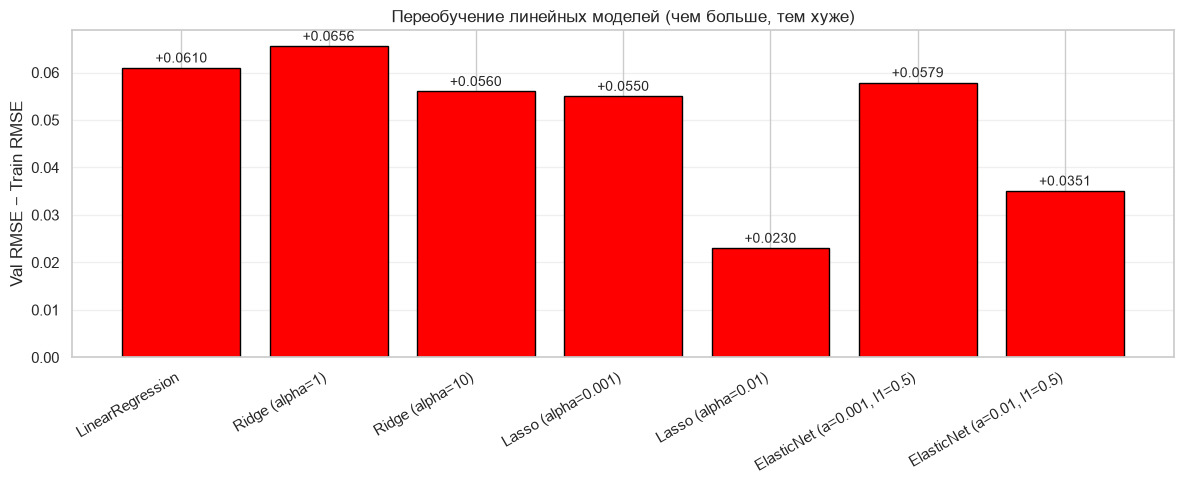

In [6]:
# переобучение: train vs val
train_rmse_lin, val_rmse_lin = {}, {}
for name, model in linear_models.items():
    model.fit(X_train_scaled, y_train)
    train_rmse_lin[name] = rmse_log(y_train, model.predict(X_train_scaled))
    val_rmse_lin[name]   = rmse_log(y_val,   model.predict(X_val_scaled))

fig, ax = plt.subplots(figsize=(12, 5))
diff = [val_rmse_lin[n] - train_rmse_lin[n] for n in linear_models]
colors = ["red" if d > 0.01 else "green" for d in diff]
bars = ax.bar(linear_models.keys(), diff, color=colors, edgecolor="black")
for bar, d in zip(bars, diff):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
            f"{d:+.4f}", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Val RMSE − Train RMSE")
ax.set_title("Переобучение линейных моделей (чем больше, тем хуже)")
ax.set_xticklabels(linear_models.keys(), rotation=30, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Лучший baseline - Lasso (α=0.01)
Почему:

Лучший holdout RMSE - 0.1493, ниже остальных.

Наименьший gap - 0.0230, то есть модель не переобучается (train и val близко).

Регуляризация L1 (Lasso) отбирает признаки - для 219 фичей (много OHE и FE) это плюс: она выкидывает неинформативные.

## 3. Деревья: K-fold CV

Для каждой модели - 5-fold CV через `cross_validate` из `src.train`.
Метрика - RMSE на log-таргете (= RMSLE).

In [7]:
tree_models = {
    "RandomForest": {
        "n_estimators": 100, "max_depth": 10, "random_state": 42,
        "n_jobs": -1, "max_leaf_nodes": 100, "min_samples_leaf": 3,
    },
    "LightGBM": {
        "n_estimators": 100, "learning_rate": 0.05, "max_depth": 5,
        "verbose": -1, "random_state": 42, "reg_alpha": 0.1,
        "reg_lambda": 0.27, "min_child_samples": 25,
    },
    "CatBoost": {
        "iterations": 357, "learning_rate": 0.05, "depth": 4,
        "verbose": False, "random_state": 42, "reg_lambda": 0.95,
    },
    "XGBoost": {
        "n_estimators": 200, "learning_rate": 0.055, "max_depth": 3,
        "random_state": 42,
    },
}

tree_cv = {}
for name, params in tree_models.items():
    model = build_model(name.lower(), params, config["task"])
    mean, std = cross_validate(model, X_train, y_train, config)
    tree_cv[name] = {"mean": mean, "std": std}
    print(f"{name:15s} CV RMSE = {mean:.4f} ± {std:.4f}")

RandomForest    CV RMSE = 0.1423 ± 0.0153
LightGBM        CV RMSE = 0.1315 ± 0.0167
CatBoost        CV RMSE = 0.1195 ± 0.0162
XGBoost         CV RMSE = 0.1269 ± 0.0174


## 4. MLP [64, 32] — честная 5-fold CV

Через `train_dnn` из `src.models` с `task="regression"` => `MSELoss`.
Метрика - RMSE на log-таргете.

In [8]:
mlp_cfg = dict(
    hidden_sizes=[64, 32],
    epochs=500,
    batch_size=32,
    lr=1e-3,
    patience=30,
    dropout=0.2,
)

kf = KFold(n_splits=config["training"]["cv_folds"], shuffle=True,
           random_state=config["training"]["random_state"])

mlp_rmses = []
for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train), 1):
    scaler_fold = StandardScaler()
    X_tr = scaler_fold.fit_transform(X_train.iloc[tr_idx]).astype("float32")
    X_va = scaler_fold.transform(X_train.iloc[va_idx]).astype("float32")
    mlp_cv = float(np.mean(mlp_rmses))
    # --- скейлим и таргет ---
    y_scaler = StandardScaler()
    y_tr = y_scaler.fit_transform(y_train[tr_idx].reshape(-1, 1)).flatten().astype("float32")
    y_va = y_scaler.transform(y_train[va_idx].reshape(-1, 1)).flatten().astype("float32")

    model, info = train_dnn(
        X_train=X_tr, y_train=y_tr,
        X_val=X_va,   y_val=y_va,
        **mlp_cfg,
        seed=42,
        task=config["task"],
    )

    with torch.no_grad():
        model.eval()
        preds_scaled = model(torch.tensor(X_va)).numpy().flatten()

    # обратный скейл, возвращаемся в log-пространство
    preds = y_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

    fold_rmse = float(np.sqrt(mean_squared_error(y_train[va_idx], preds)))
    mlp_rmses.append(fold_rmse)
    print(f"Fold {fold}: MLP [64,32] RMSE = {fold_rmse:.4f} "
          f"(best_val_loss_scaled={info['best_val_loss']:.5f})")

c:\Users\xmxlx\Desktop\housing-ml\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\xmxlx\Desktop\housing-ml\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[DNN] Early stopping на эпохе 55 (best val=0.13425)
Fold 1: MLP [64,32] RMSE = 0.1416 (best_val_loss_scaled=0.13425)
[DNN] Early stopping на эпохе 45 (best val=0.10489)
Fold 2: MLP [64,32] RMSE = 0.1260 (best_val_loss_scaled=0.10489)
[DNN] Early stopping на эпохе 39 (best val=0.23528)
Fold 3: MLP [64,32] RMSE = 0.1869 (best_val_loss_scaled=0.23528)
[DNN] Early stopping на эпохе 67 (best val=0.08929)
Fold 4: MLP [64,32] RMSE = 0.1180 (best_val_loss_scaled=0.08929)
[DNN] Early stopping на эпохе 49 (best val=0.09622)
Fold 5: MLP [64,32] RMSE = 0.1230 (best_val_loss_scaled=0.09622)


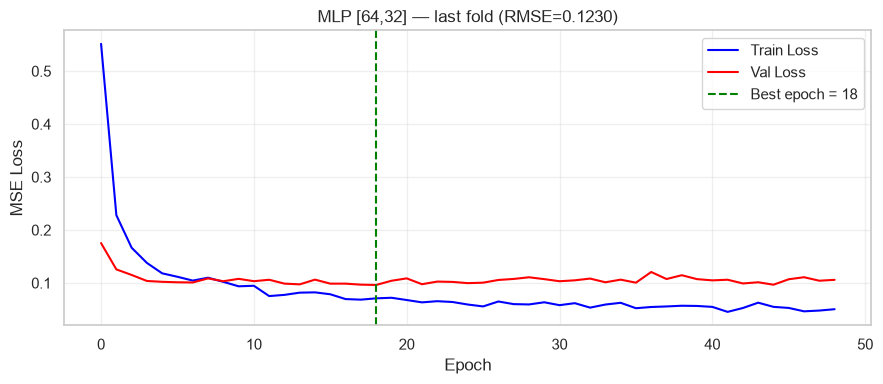

In [9]:
# loss-кривая последнего фолда
hist = info["history"]
plt.figure(figsize=(9, 4))
plt.plot(hist["train_loss"], label="Train Loss", color="blue")
plt.plot(hist["val_loss"],   label="Val Loss",   color="red")
plt.axvline(int(np.argmin(hist["val_loss"])), color="green", ls="--",
            label=f"Best epoch = {int(np.argmin(hist['val_loss']))}")
plt.title(f"MLP [64,32] — last fold (RMSE={mlp_rmses[-1]:.4f})")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Сводная таблица результатов

In [10]:
# все приводим к CV со st scaler внутри, чтобы в таблице не было путаницы + sk.learn.Pipeline, т.к. cross_validate сам не скейлит
linear_cv = {}
for name, model in linear_models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model),
    ])
    mean, std = cross_validate(pipe, X_train, y_train, config)
    linear_cv[name] = mean
    print(f"{name:35s} CV RMSE = {mean:.4f} ± {std:.4f}")

summary_rows = []
for name, r in linear_cv.items():
    summary_rows.append({"Model": name, "CV RMSE": r})
for name, r in tree_cv.items():
    summary_rows.append({"Model": name, "CV RMSE": r["mean"]})
summary_rows.append({"Model": "MLP [64,32]", "CV RMSE": mlp_cv})

summary_df = pd.DataFrame(summary_rows).sort_values("CV RMSE")
summary_df.style.hide(axis="index")

LinearRegression                    CV RMSE = 0.1636 ± 0.0394
Ridge (alpha=1)                     CV RMSE = 0.1564 ± 0.0303
Ridge (alpha=10)                    CV RMSE = 0.1524 ± 0.0298
Lasso (alpha=0.001)                 CV RMSE = 0.1493 ± 0.0312
Lasso (alpha=0.01)                  CV RMSE = 0.1485 ± 0.0335
ElasticNet (a=0.001, l1=0.5)        CV RMSE = 0.1510 ± 0.0311
ElasticNet (a=0.01, l1=0.5)         CV RMSE = 0.1460 ± 0.0335


Model,CV RMSE
CatBoost,0.119468
XGBoost,0.126945
LightGBM,0.131504
RandomForest,0.142263
"MLP [64,32]",0.143101
"ElasticNet (a=0.01, l1=0.5)",0.145998
Lasso (alpha=0.01),0.148465
Lasso (alpha=0.001),0.149322
"ElasticNet (a=0.001, l1=0.5)",0.150982
Ridge (alpha=10),0.152406


## 6. Финальная модель + holdout

In [11]:

final_name = config["model"]["name"]
final_model = build_model(final_name.lower(), config["model"]["params"], config["task"])
final_model.fit(X_train, y_train)
val_pred = final_model.predict(X_val)

holdout_rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))
print(f"Финальная модель: {final_name}")
print(f"CV RMSE (5-fold):    {tree_cv['CatBoost']['mean']:.4f} ± {tree_cv['CatBoost']['std']:.4f}")
print(f"Holdout RMSE:        {holdout_rmse:.4f}")
print(f"|holdout − CV| =     {abs(holdout_rmse - tree_cv['CatBoost']['mean']):.4f}")

Финальная модель: catboost
CV RMSE (5-fold):    0.1195 ± 0.0162
Holdout RMSE:        0.1360
|holdout − CV| =     0.0165


1. CV и holdout согласуются. Разница 0.0165 - чуть больше одного std (0.0162). То есть holdout попадает в диапазон [CV - 1.1×std, CV + 1.1×std]. Это хорошо: сплит репрезентативен, CV не завышен, модель не переобучена на конкретную выборку.

2. Модель стабильна. Если бы holdout был 0.25 при CV 0.12 - был бы редфлаг

3. Std по фолдам = 0.0162 - это ~13% от среднего. Для housing это много, но ожидаемо: у нас 1460 примеров, разбитых на 5 фолдов => по 292 примера в каждом val.